In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import seaborn as sns
#!pip install catboost
from sklearn.model_selection import StratifiedKFold

In [2]:
df_train = pd.read_csv('TrainData/train.csv')
df_train = df_train.drop(['ID','generation'], axis=1)

df_test = pd.read_csv('OriginalData/test.csv')
df_test = df_test.drop(['ID','generation'], axis=1)

df_train.head()
df_train.head()

,school1,major type,major1_1,major1_2,major_data,job,class1,class2,class3,class4,...,incumbents_company_level,incumbents_lecture_type,incumbents_lecture_scale,incumbents_lecture_scale_reason,interested_company,expected_domain,contest_participation,idea_contest,onedayclass_topic,completed
0,22,"복수 전공 ( 다중전공, 이중전공 포함 )",경제통상학,자연과학,False,대학생,1,4.0,NaN,NaN,...,해외 기업 (빅테크),"온, 오프라인 동시",100명 이상의 리스너와 10명 이상의 현직자,다양한 사람들과 만나서 생각을 교류할 수 있기 때문,"구글 딥마인드, 카카오 브레인","M. 전문, 과학 및 기술 서비스업",NaN,NaN,"Python 응용, 데이터 시각화 (Matplotlib, Seaborn 등), 머신...",0
1,1,"복수 전공 ( 다중전공, 이중전공 포함 )",자연과학,IT(컴퓨터 공학 포함),True,대학생,8,NaN,NaN,NaN,...,국내 빅테크 IT 계열 (네카라쿠배당토),오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,더 많은 사람들이 있으면 제가 예상하지 못한 질문도 할 수 있다고 생각하기 때문입니다.,제일 기획,"J. 정보통신업, O. 공공 행정, 국방 및 사회보장 행정",NaN,NaN,머신러닝 / 딥러닝 응용,0
2,27,단일 전공,예체능,NaN,False,대학생,7,NaN,NaN,NaN,...,"국내 대기업 IT 계열 (금융, 제조 ...)",오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,인원이 너무 적으면 서로 부담스러울 수 있을 것 같지만 너무 많으면 너무 피상적인 ...,Lg전자,"C. 제조업, K. 금융 및 보험업, R. 예술, 스포츠 및 여가관련 서비스업",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0
3,1,"복수 전공 ( 다중전공, 이중전공 포함 )",사회과학,IT(컴퓨터 공학 포함),False,대학생,7,NaN,NaN,NaN,...,국내 빅테크 IT 계열 (네카라쿠배당토),"온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,너무 많은 인원이 강의하면 루즈해질 것 같아서,네이버,"J. 정보통신업, K. 금융 및 보험업",NaN,NaN,머신러닝 / 딥러닝 응용,1
4,16,"복수 전공 ( 다중전공, 이중전공 포함 )",IT(컴퓨터 공학 포함),IT(컴퓨터 공학 포함),True,대학생,8,NaN,NaN,NaN,...,"국내 대기업 IT 계열 (금융, 제조 ...)","온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,다양한 사람들에게 기회가 있으면 좋겠습니다.,네이버,"K. 금융 및 보험업, M. 전문, 과학 및 기술 서비스업, R. 예술, 스포츠 및...",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0


In [3]:
def make_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 유입경로 그룹화
    def route_group(x):
        x = str(x)
        if ('에브리타임' in x) or ('교내' in x):
            return '커뮤니티'
        if '인스타' in x:
            return 'SNS'
        if ('기존' in x) or ('오픈채팅' in x) or ('학회원' in x):
            return '내부 네트워크'
        if '지인' in x:
            return '지인'
        if ('대외활동' in x) or ('링커리어' in x) or ('캠퍼' in x):
            return '대외활동 플랫폼'
        if ('블라인드' in x) or ('링크드인' in x):
            return '직장인 커뮤니티'
        if ('행사' in x) or ('페스티벌' in x) or ('wave' in x.lower()):
            return '행사'
        if ('검색' in x) or ('블로그' in x):
            return '검색/블로그'
        return '기타'

    if 'inflow_route' in df.columns:
        df['inflow_route'] = df['inflow_route'].apply(route_group)

    # 참여 시간
    def time_band(x):
        # time_input이 NaN일 수 있으니 안전 처리
        if pd.isna(x):
            return 'missing_time'
        if x < 2:
            return 'low_time'
        elif 2 <= x <= 5:
            return 'optimal_time'
        else:
            return 'over_time'

    if 'time_input' in df.columns:
        df['time_band'] = df['time_input'].apply(time_band)

    # 전공 그룹화 (major1_1)
    def major_group(val):
        if pd.isna(val):
            return '미응답'
        x = str(val).strip().lower()

        if any(k in x for k in ['컴퓨터','소프트웨어','ai','데이터','정보','통신','전자','전기','공학','it','인공지능']):
            return 'IT(컴퓨터 공학 포함)'
        if any(k in x for k in ['경영','경제','금융','무역','통상','회계']):
            return '경영학'
        if any(k in x for k in ['수학','통계','물리','화학','생명','과학']):
            return '자연과학'
        if any(k in x for k in ['심리','사회','행정','정치','외교','언론','미디어']):
            return '사회과학'
        if any(k in x for k in ['영어','국어','문학','어학','철학','사학']):
            return '인문학'
        if '법' in x:
            return '법학'
        if any(k in x for k in ['의학','약학','보건','간호','의예']):
            return '의약학'
        if '교육' in x:
            return '교육학'
        if any(k in x for k in ['디자인','체육','음악','미술','예술','스포츠']):
            return '예체능'
        return '기타'

    if 'major1_1' in df.columns:
        df['major1_1'] = df['major1_1'].apply(major_group)

    # 이수학기
    if 'completed_semester' in df.columns:
        df['completed_semester'] = pd.to_numeric(df['completed_semester'], errors='coerce')
        df['completed_semester'] = df['completed_semester'].where(df['completed_semester'].between(1, 10))
        df['completed_semester'] = df['completed_semester'].fillna(0)

    # 자격증 리스트/개수
    def clean_cert(x):
        if isinstance(x, list):
            x = ','.join(x)
        x = str(x)

        invalid = {'없음', '기타', '준비중'}
        out = []
        for i in x.split(','):
            t = i.strip()
            if (t == '') or (t == 'nan'):
                continue
            if t in invalid:
                continue
            if t.startswith('준비중'):
                continue
            out.append(t)
        return out

    if 'certificate_acquisition' in df.columns:
        df['cert_list'] = df['certificate_acquisition'].apply(clean_cert)
        df['cert_cnt'] = df['cert_list'].apply(len)
    else:
        df['cert_cnt'] = 0

    # 학습 의지
    if 'onedayclass_topic' in df.columns:
        topics = df['onedayclass_topic'].fillna('').astype(str).str.strip()
        topics = (topics
                  .str.replace('데이터 시각화 (Matplotlib, Seaborn 등)', 'DATA_VIZ', regex=False)
                  .str.replace('머신러닝 / 딥러닝 응용', 'ML_DL', regex=False))

        topic_map = {
            'Python 응용': 'python',
            'SQL 응용': 'sql',
            '웹 크롤링': 'crawl',
            'DATA_VIZ': 'viz',
            'ML_DL': 'ml'
        }

        for raw, name in topic_map.items():
            df[f'topic_{name}'] = topics.str.contains(raw, regex=False).astype(int)

        df['topic_count'] = topics.apply(lambda x: 0 if x == '' else len([p.strip() for p in x.split(',') if p.strip()]))
        df['topic_count'] = df['topic_count'].clip(upper=5)
    else:
        for name in ['python','sql','crawl','viz','ml']:
            df[f'topic_{name}'] = 0
        df['topic_count'] = 0

    # 이전 참여 경험/횟수
    prev_cols = [c for c in df.columns if c.startswith('previous_class_')]
    if len(prev_cols) > 0:
        df['prev_class_cnt'] = (
            df[prev_cols]
            .apply(lambda col: col.astype(str).str.findall(r'000\d'))
            .applymap(len)
            .sum(axis=1)
            .astype(int)
        )
    else:
        df['prev_class_cnt'] = 0

    df['has_previous'] = (df['prev_class_cnt'] > 0).astype(int)

    # 현재 수강 과목 개수
    class_cols = [c for c in ['class1', 'class2', 'class3', 'class4'] if c in df.columns]
    if len(class_cols) > 0:
        df['class_cnt'] = df[class_cols].notna().sum(axis=1).astype(int)
    else:
        df['class_cnt'] = 0


    return df

def target_dependent_features_oof(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    n_splits: int = 3,          #모델 CV(현재 3fold)랑 맞추기
    smoothing: float = 20.0,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    df_train = df_train.copy()
    df_test = df_test.copy()

    # =========================
    # 1) desired_job -> job_cnt (누수 없음)
    # =========================
    df_train['desired_job_list'] = (
        df_train['desired_job'].fillna("").astype(str).str.findall(r'\b([A-J])\.')
    )
    df_test['desired_job_list'] = (
        df_test['desired_job'].fillna("").astype(str).str.findall(r'\b([A-J])\.')
    )
    df_train['job_cnt'] = df_train['desired_job_list'].apply(len)
    df_test['job_cnt'] = df_test['desired_job_list'].apply(len)

    df_train.drop(columns=['desired_job_list'], inplace=True, errors='ignore')
    df_test.drop(columns=['desired_job_list'], inplace=True, errors='ignore')

    # =========================
    # 2) time_input -> time_risk (OOF target encoding + smoothing)
    # =========================
    if ('time_input' in df_train.columns) and ('completed' in df_train.columns):
        y = df_train['completed'].values
        oof_rate = np.zeros(len(df_train), dtype=float)

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

        for tr_idx, va_idx in skf.split(df_train, y):
            fold_tr = df_train.iloc[tr_idx]
            global_rate = fold_tr['completed'].mean()

            stats = fold_tr.groupby('time_input')['completed'].agg(['count', 'mean'])
            smoothed = (stats['count'] * stats['mean'] + smoothing * global_rate) / (stats['count'] + smoothing)

            oof_rate[va_idx] = (
                df_train.iloc[va_idx]['time_input']
                .map(smoothed)
                .fillna(global_rate)
                .values
            )

        # train: OOF 기반 (각 행은 자기 타깃을 보지 않음)
        df_train['time_risk'] = 1.0 - oof_rate

        # test: 전체 train 통계 기반(누수 아님)
        global_rate_all = df_train['completed'].mean()
        stats_all = df_train.groupby('time_input')['completed'].agg(['count', 'mean'])
        smoothed_all = (stats_all['count'] * stats_all['mean'] + smoothing * global_rate_all) / (stats_all['count'] + smoothing)

        df_test['time_risk'] = 1.0 - df_test['time_input'].map(smoothed_all).fillna(global_rate_all)

    else:
        df_train['time_risk'] = np.nan
        df_test['time_risk'] = np.nan

    return df_train, df_test


def added_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # 여기에 추가적인 파생변수 생성 코드를 작성하세요.
    #-------------------------추가---------------------------
    # 준비도 지표
    df['prep_score'] = df['cert_cnt'] + df['topic_count']

    # 지속성 지표
    df['class_ratio'] = df['prev_class_cnt'] / df['class_cnt'].replace(0, np.nan)

    #sqld&빅분기 관련 지표
    df['sqld_cert'] = df['cert_list'].apply(lambda x: 1 if 'SQLD' in x else 0)
    df['bigdata_cert'] = df['cert_list'].apply(lambda x: 1 if '빅데이터' in x else 0)
    df['else_cert'] = (df['cert_cnt'] - (df['sqld_cert'] + df['bigdata_cert'])) > 0

    # 가중치 부여한 자격증 개수
    df['cert_weighted'] = df['cert_cnt'] + df['bigdata_cert'] + df['sqld_cert']

    #offline 여부
    df['offline'] = df['hope_for_group'].map({
        '네. 오프라인으로 참여하고 싶어요': 1,
        '네. 온라인으로 참여하고 싶어요': 0
    }).fillna(-1)

    df['prep_score_bin'] = pd.qcut(
        df['prep_score'], q=5, labels=False, duplicates='drop'
    )

    df['cert_cnt_bin'] = pd.qcut(
        df['cert_cnt'], q=5, labels=False, duplicates='drop'
    )
    df['var1'] = df['prep_score'] * df['topic_count']
    df['var2'] = df['prep_score'] * df['cert_cnt']
    df['var3'] = df['job_cnt'] * df['prep_score']
    df['var4'] =  df['completed_semester'] / df['prep_score']
    df['var5'] = df['completed_semester'] / df['job_cnt']

    for col in ['var4','var5']:
        finite_vals = df.loc[np.isfinite(df[col]), col]
        max_val = finite_vals.max()
        df.loc[np.isinf(df[col]), col] = max_val * 1.1

    return df


df_train = make_features(df_train)
df_test  = make_features(df_test)

df_train, df_test = target_dependent_features_oof(df_train, df_test, n_splits=3, smoothing=20, random_state=42)

df_train = added_features(df_train)
df_test  = added_features(df_test)



/var/folders/7x/ckht72xn7276hfpwcr1r7vwr0000gn/T/ipykernel_1811/1783032338.py:134: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(len)
/var/folders/7x/ckht72xn7276hfpwcr1r7vwr0000gn/T/ipykernel_1811/1783032338.py:134: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(len)


In [4]:
######################## 0209catlr에서 추가한 피처###################################3

import pandas as pd
import numpy as np

def engineer_features(df):
    # 원본 데이터 훼손 방지를 위한 카피
    df = df.copy()

    # 1. 성실도 점수 (Sincerity Score)
    text_cols = ['whyBDA', 'what_to_gain', 'incumbents_lecture_scale_reason']
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].fillna('')

    # 텍스트 컬럼이 존재할 때만 계산
    df['sincerity_score'] = 0
    for col in text_cols:
        if col in df.columns:
            df['sincerity_score'] += df[col].str.len()

    # 2. 경험자 여부 (is_experienced)
    prev_cols = df.filter(like='previous_class').columns

    def check_exp(row):
        re_reg = 1 if str(row.get('re_registration', '')) == '예' else 0
        has_prev = 0
        for col in prev_cols:
            val = str(row[col])
            if val != '해당없음' and val != 'nan' and val.strip() != '':
                has_prev = 1
                break
        return 1 if (re_reg == 1 or has_prev == 1) else 0

    df['is_experienced'] = df.apply(check_exp, axis=1)

    # 3. 고학년 절박함 지수 (senior_urgency)
    # numeric 변환 시 에러 대비
    sem_val = pd.to_numeric(df['completed_semester'], errors='coerce').fillna(0)
    time_val = pd.to_numeric(df['time_input'], errors='coerce').fillna(0)
    df['senior_urgency'] = sem_val * time_val

    # 4. 목표 일치도 점수 (goal_alignment_score)
    def calculate_alignment(row):
        job = str(row.get('desired_job', ''))
        topic = str(row.get('onedayclass_topic', ''))
        keywords = ['분석', '데이터', '머신러닝', '딥러닝', 'SQL', 'Python', '파이썬', '시각화', '마케팅', '엔지니어', '개발', '기획']

        score = 0
        for kw in keywords:
            if kw in job and kw in topic:
                score += 1
        return score

    df['goal_alignment_score'] = df.apply(calculate_alignment, axis=1)

    return df

# --- 실제 적용 ---
df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

print("df_train 피처 생성 완료:", df_train.shape)
print("df_test 피처 생성 완료:", df_test.shape)

df_train 피처 생성 완료: (748, 76)
df_test 피처 생성 완료: (814, 75)


In [5]:
df_train.columns

Index(['school1', 'major type', 'major1_1', 'major1_2', 'major_data', 'job',
       'class1', 'class2', 'class3', 'class4', 're_registration',
       'contest_award', 'nationality', 'inflow_route', 'whyBDA',
       'what_to_gain', 'hope_for_group', 'previous_class_3',
       'previous_class_4', 'previous_class_5', 'previous_class_6',
       'previous_class_7', 'previous_class_8', 'major_field',
       'desired_career_path', 'completed_semester', 'project_type',
       'time_input', 'desired_job', 'certificate_acquisition',
       'desired_certificate', 'desired_job_except_data', 'incumbents_level',
       'incumbents_lecture', 'incumbents_company_level',
       'incumbents_lecture_type', 'incumbents_lecture_scale',
       'incumbents_lecture_scale_reason', 'interested_company',
       'expected_domain', 'contest_participation', 'idea_contest',
       'onedayclass_topic', 'completed', 'time_band', 'cert_list', 'cert_cnt',
       'topic_python', 'topic_sql', 'topic_crawl', 'topic_viz', '

### 상관관계 확인

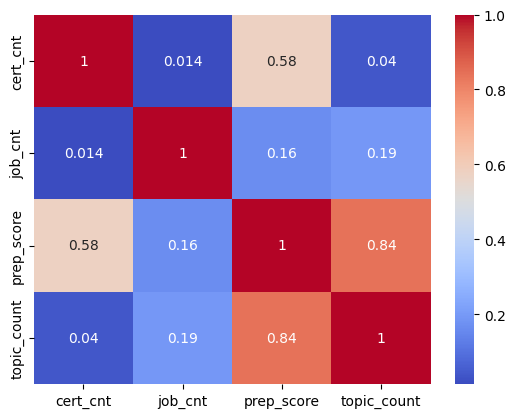

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_train[['cert_cnt','job_cnt','prep_score','topic_count']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


## 최적 피쳐 도출

In [7]:
from catboost import (
    CatBoostClassifier,
    Pool,
    EFeaturesSelectionAlgorithm,
    EShapCalcType
)

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score

# =========================
# 0) 컬럼 정리
# =========================
df_train.columns = df_train.columns.str.strip()
df_test.columns  = df_test.columns.str.strip()

# =========================
# 1) 기본 피처 정의
# =========================
BASE_FEATURES = [
    "completed_semester","inflow_route","major1_1",
    "project_type","cert_cnt","time_risk","job_cnt", "topic_count",
    "re_registration","hope_for_group","job","class_cnt",
    "prev_class_cnt","has_previous", "time_band", "time_input",
    "incumbents_company_level",
    'prep_score', 'class_ratio',
    'sqld_cert', 'bigdata_cert', 'else_cert', 'cert_weighted',
    'offline',
    'var1', 'var2', 'var3', 'var4', 'var5',
    'prep_score_bin', 'cert_cnt_bin','sincerity_score', 'is_experienced', 'senior_urgency', 'goal_alignment_score'
]

TARGET = "completed"

# =========================
# 2) 결측 보정
# =========================
def ensure_features(df, features):
    df = df.copy()
    for c in features:
        if c not in df.columns:
            df[c] = "missing" if df[c].dtype=="object" else 0
    return df

df_train = ensure_features(df_train, BASE_FEATURES+[TARGET])
df_test  = ensure_features(df_test, BASE_FEATURES)

# =========================
# 3) 데이터 준비
# =========================
X_all = df_train[BASE_FEATURES].copy()
y_all = df_train[TARGET].copy()
X_test_all = df_test[BASE_FEATURES].copy()

# 문자열 컬럼 자동 감지
for col in X_all.select_dtypes(include="object").columns:
    X_all[col] = X_all[col].astype(str)
    X_test_all[col] = X_test_all[col].astype(str)

# =========================
# 4) FS용 split (누수 방지)
# =========================
X_fs, _, y_fs, _ = train_test_split(
    X_all, y_all,
    test_size=0.3,
    stratify=y_all,
    random_state=42
)

base_cat = X_fs.select_dtypes(include="object").columns.tolist()

# =========================
# 5) k 탐색
# =========================
k_range = range(5, min(len(BASE_FEATURES),25))

best_global_f1 = 0
best_k = None
best_selected = None

for k in k_range:
    print(f"\n========== k={k} ==========")

    # -------- FS --------
    fs_model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        l2_leaf_reg=25,
        min_data_in_leaf=20,
        auto_class_weights="None", #가중치 없애고 오로지 피처만 판단
        loss_function="Logloss",
        early_stopping_rounds=100,
        random_seed=42,
        verbose=0
    )


    fs_pool = Pool(X_fs, y_fs, cat_features=base_cat)

    fs_result = fs_model.select_features(
        fs_pool,
        features_for_select=list(range(X_fs.shape[1])),
        num_features_to_select=k,
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False
    )

    selected = [BASE_FEATURES[i] for i in fs_result["selected_features"]]
    print("Selected:", selected)

    # -------- 데이터 반영 --------
    X = X_all[selected].copy()
    y = y_all.copy()

    cat_features = X.select_dtypes(include="object").columns.tolist()

    # -------- CV --------
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    oof_pred = np.zeros(len(X))

    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=5,
        l2_leaf_reg=25,
        min_data_in_leaf=50,
        auto_class_weights="None",
        loss_function="Logloss",
        eval_metric="AUC",
        custom_metric=["F1","AUC"],
        random_seed=42,
        early_stopping_rounds=200,
        verbose=200
    )

    for tr, va in skf.split(X, y):
        tr_pool = Pool(X.iloc[tr], y.iloc[tr], cat_features=cat_features)
        va_pool = Pool(X.iloc[va], y.iloc[va], cat_features=cat_features)

        model.fit(tr_pool, eval_set=va_pool, use_best_model=True)
        oof_pred[va] = model.predict_proba(va_pool)[:,1]

    # -------- F1 --------
    best_f1 = 0
    for t in np.arange(0.1,0.9,0.02):
        f1 = f1_score(y,(oof_pred>=t).astype(int))
        best_f1 = max(best_f1,f1)

    print(f"k={k} → F1={best_f1:.5f}")

    if best_f1 > best_global_f1:
        best_global_f1 = best_f1
        best_k = k
        best_selected = selected

print("\n====== RESULT ======")
print("BEST k:", best_k)
print("BEST F1:", best_global_f1)
print("BEST FEATURES:", best_selected)



========== k=5 ==========
Step #1 out of 1
Feature #20 eliminated
Feature #8 eliminated
Feature #30 eliminated
Feature #32 eliminated
Feature #13 eliminated
Feature #4 eliminated
Feature #34 eliminated
Feature #12 eliminated
Feature #21 eliminated
Feature #3 eliminated
Feature #19 eliminated
Feature #29 eliminated
Feature #15 eliminated
Feature #7 eliminated
Feature #17 eliminated
Feature #6 eliminated
Feature #18 eliminated
Feature #14 eliminated
Feature #23 eliminated
Feature #11 eliminated
Feature #22 eliminated
Feature #27 eliminated
Feature #28 eliminated
Feature #16 eliminated
Feature #24 eliminated
Feature #26 eliminated
Feature #0 eliminated
Feature #10 eliminated
Feature #33 eliminated
Feature #1 eliminated
Selected: ['major1_1', 'time_risk', 'hope_for_group', 'var2', 'sincerity_score']
0:	test: 0.5133714	best: 0.5133714 (0)	total: 1ms	remaining: 2s
200:	test: 0.5660952	best: 0.5873143 (20)	total: 158ms	remaining: 1.41s
Stopped by overfitting detector  (200 iterations wait)



# optuna

In [8]:
# 먼저 Optuna 설치 (처음 한 번만)
# !pip install optuna

import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier, Pool
import numpy as np

# =========================
# 1) 데이터 준비
# =========================
FINAL_FEATURES = best_selected

X = df_train[FINAL_FEATURES].copy()
y = df_train["completed"].copy()
X_test = df_test[FINAL_FEATURES].copy()

cat_features = X.select_dtypes(include="object").columns.tolist()

for c in cat_features:
    X[c] = X[c].astype(str)
    X_test[c] = X_test[c].astype(str)

# 3-Fold CV
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# =========================
#find_best_threshold 함수 정의
# =========================
def find_best_threshold(y_true, proba, t_min=0.05, t_max=0.95, step=0.01):
    best_f1, best_t = -1.0, None
    for t in np.arange(t_min, t_max + 1e-9, step):
        f1 = f1_score(y_true, (proba >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


# =========================
# 2) Objective Function 정의
# =========================
def objective(trial):
    """
    Optuna가 최적화할 목적 함수
    각 trial마다 다른 하이퍼파라미터 조합을 시도
    """
    # 탐색할 하이퍼파라미터 범위 정의
    params = {
        'iterations': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float("l2_leaf_reg", 1.0, 50.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),

        # Class weights - None
        'auto_class_weights': None,
        'class_weights': None,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'early_stopping_rounds': 200,
        'verbose': False
    }

    oof_pred = np.zeros(len(X), dtype=float)

    # CV 학습
    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        tr_pool = Pool(X.iloc[tr], y.iloc[tr], cat_features=cat_features)
        va_pool = Pool(X.iloc[va], y.iloc[va], cat_features=cat_features)

        model = CatBoostClassifier(**params)
        model.fit(tr_pool, eval_set=va_pool, use_best_model=True)

        oof_pred[va] = model.predict_proba(va_pool)[:, 1]

    # OOF 기준 threshold 최적화해서 F1 반환
    _, best_f1 = find_best_threshold(y, oof_pred, t_min=0.05, t_max=0.95, step=0.01)
    return best_f1

# =========================
# 3) Optuna 실행
# =========================
print("🔍 하이퍼파라미터 최적화 시작")

# Study 생성
study = optuna.create_study(
    direction='maximize',  # F1 스코어를 최대화
    sampler=TPESampler(seed=42),
    study_name='catboost_f1_opt_no_weights'
)

#최적화 실행(50번 다른 조합)
study.optimize(objective, n_trials=50, show_progress_bar=True, n_jobs=1)  # 병렬 처리 (1=순차, -1=모든 코어)

print("\n✅ Optuna Best F1:", study.best_value)
print("✅ Best Params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# =========================
# 4) Best Params로 OOF/Test 예측 함수
# =========================
def fit_oof_and_test(base_params, class_weights=None):
    """
    base_params: optuna best_params 기반(learn_rate, depth 등)
    class_weights: None 또는 [w0, w1]
    """
    params = dict(base_params)
    params.update({
        "iterations": 2000,
        "auto_class_weights": None,
        "class_weights": class_weights,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": 42,
        "early_stopping_rounds": 200,
        "verbose": False,
    })

    oof = np.zeros(len(X), dtype=float)
    test_pred = np.zeros(len(X_test), dtype=float)

    te_pool = Pool(X_test, cat_features=cat_features)

    for tr_idx, va_idx in skf.split(X, y):
        tr_pool = Pool(X.iloc[tr_idx], y.iloc[tr_idx], cat_features=cat_features)
        va_pool = Pool(X.iloc[va_idx], y.iloc[va_idx], cat_features=cat_features)

        model = CatBoostClassifier(**params)
        model.fit(tr_pool, eval_set=va_pool, use_best_model=True)

        oof[va_idx] = model.predict_proba(va_pool)[:, 1]
        test_pred += model.predict_proba(te_pool)[:, 1] / skf.n_splits

    best_thr, best_f1 = find_best_threshold(y, oof, 0.05, 0.95, 0.01)

    return {
        "params": params,
        "class_weights": class_weights,
        "oof": oof,
        "test_pred": test_pred,
        "best_thr": best_thr,
        "best_f1": best_f1,
    }

# =========================
# 5) 1차: weight 없이 최종 OOF/thr
# =========================
base_params = study.best_params
res_none = fit_oof_and_test(base_params, class_weights=None)

print("\n===== [NO WEIGHT] =====")
print("Best F1:", res_none["best_f1"])
print("Best thr:", res_none["best_thr"])
pred_test_none = (res_none["test_pred"] >= res_none["best_thr"]).astype(int)
print("Test pos rate:", pred_test_none.mean(), f"({pred_test_none.sum()}/{len(pred_test_none)})")

# =========================
# 6) 최적 파라미터 저장 (재사용)
# =========================
best_params = res_none["params"]

print(f"\n💾 최적 파라미터를 복사해서 사용하세요:")
print("-"*70)
print("model = CatBoostClassifier(")

for key, value in best_params.items():
    if isinstance(value, str):
        print(f"    {key}='{value}',")
    else:
        print(f"    {key}={value},")
print(")")

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-21 22:38:00,974] A new study created in memory with name: catboost_f1_opt_no_weights


🔍 하이퍼파라미터 최적화 시작


Best trial: 0. Best value: 0.487141:   2%|▏         | 1/50 [00:04<03:24,  4.17s/it]

[I 2026-02-21 22:38:05,169] Trial 0 finished with value: 0.48714069591527986 and parameters: {'learning_rate': 0.023688639503640783, 'depth': 8, 'l2_leaf_reg': 17.524101118128137, 'min_data_in_leaf': 64, 'random_strength': 1.5601864044243652}. Best is trial 0 with value: 0.48714069591527986.


Best trial: 0. Best value: 0.487141:   4%|▍         | 2/50 [00:05<01:53,  2.37s/it]

...

[I 2026-02-21 22:39:23,214] Trial 47 finished with value: 0.48581997533908755 and parameters: {'learning_rate': 0.08590262850088036, 'depth': 3, 'l2_leaf_reg': 29.43298990936634, 'min_data_in_leaf': 17, 'random_strength': 7.212822100405662}. Best is trial 28 with value: 0.49592169657422513.


Best trial: 28. Best value: 0.495922:  98%|█████████▊| 49/50 [01:23<00:01,  1.47s/it]

[I 2026-02-21 22:39:24,603] Trial 48 finished with value: 0.4828532235939643 and parameters: {'learning_rate': 0.029233735411824724, 'depth': 4, 'l2_leaf_reg': 2.658790361556114, 'min_data_in_leaf': 60, 'random_strength': 9.982835861660032}. Best is trial 28 with value: 0.49592169657422513.


Best trial: 49. Best value: 0.512121: 100%|██████████| 50/50 [01:25<00:00,  1.72s/it]


[I 2026-02-21 22:39:26,862] Trial 49 finished with value: 0.5121212121212121 and parameters: {'learning_rate': 0.015672700658685524, 'depth': 5, 'l2_leaf_reg': 1.2003009306153432, 'min_data_in_leaf': 92, 'random_strength': 8.254343249513376}. Best is trial 49 with value: 0.5121212121212121.

✅ Optuna Best F1: 0.5121212121212121
✅ Best Params:
  learning_rate: 0.015672700658685524
  depth: 5
  l2_leaf_reg: 1.2003009306153432
  min_data_in_leaf: 92
  random_strength: 8.254343249513376

===== [NO WEIGHT] =====
Best F1: 0.5121212121212121
Best thr: 0.29000000000000004
Test pos rate: 0.6793611793611793 (553/814)

💾 최적 파라미터를 복사해서 사용하세요:
----------------------------------------------------------------------
model = CatBoostClassifier(
    learning_rate=0.015672700658685524,
    depth=5,
    l2_leaf_reg=1.2003009306153432,
    min_data_in_leaf=92,
    random_strength=8.254343249513376,
    iterations=2000,
    auto_class_weights=None,
    class_weights=None,
    loss_function='Logloss',
    ev

In [9]:
# =========================
# 1) 최종 피처 적용
# =========================
FINAL_FEATURES = best_selected

X = df_train[FINAL_FEATURES].copy()
y = df_train["completed"].copy()
X_test = df_test[FINAL_FEATURES].copy()

# categorical 자동 처리
cat_features = X.select_dtypes(include="object").columns.tolist()

for c in cat_features:
    X[c] = X[c].astype(str)
    X_test[c] = X_test[c].astype(str)

# =========================
# 2) CV 설정
# =========================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

oof_pred = np.zeros(len(X))
test_pred = np.zeros(len(X_test))

# =========================
# 3) 최적 파라미터 설정, CatBoost 모델 CV 학습
# =========================
cb_params = dict(
    learning_rate=0.09870909742558537,
    depth=6,
    l2_leaf_reg=5.603795561726096,
    min_data_in_leaf=66,
    random_strength=6.478397173569881,
    iterations=2000,
    auto_class_weights=None,
    class_weights=None,
    loss_function='Logloss',
    eval_metric='AUC',
    custom_metric=["F1","AUC"],
    random_seed=42,
    early_stopping_rounds=200,
    verbose=200
)

te_pool = Pool(X_test,cat_features=cat_features) #X_test는 항상 동일해서 한번만 생성, 매 fold마다 Pool()새로 생성할 필요없음

for fold,(tr,va) in enumerate(skf.split(X,y),1):
    print(f"\n===== Fold {fold} =====")

    tr_pool = Pool(X.iloc[tr],y.iloc[tr],cat_features=cat_features)
    va_pool = Pool(X.iloc[va],y.iloc[va],cat_features=cat_features)

    model = CatBoostClassifier(**cb_params) #fold마다 새 모델 만들어야함
    model.fit(tr_pool,eval_set=va_pool,use_best_model=True)

    oof_pred[va] = model.predict_proba(va_pool)[:,1]
    test_pred += model.predict_proba(te_pool)[:,1]/skf.n_splits

# =========================
# 4) Threshold 최적화
# =========================
best_thr,best_f1 = 0,0

for t in np.arange(0.05,0.95,0.01):
    f1 = f1_score(y,(oof_pred>=t).astype(int))
    if f1>best_f1:
        best_f1,best_thr = f1,t

print("Best threshold:",best_thr,"F1:",best_f1)

pred_test = (test_pred>=best_thr).astype(int)


===== Fold 1 =====
0:	test: 0.4571810	best: 0.4571810 (0)	total: 4.18ms	remaining: 8.36s
200:	test: 0.6107429	best: 0.6245333 (101)	total: 343ms	remaining: 3.07s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.6245333333
bestIteration = 101

Shrink model to first 102 iterations.

===== Fold 2 =====
0:	test: 0.5627799	best: 0.5627799 (0)	total: 3.44ms	remaining: 6.87s
200:	test: 0.5589961	best: 0.6181853 (3)	total: 373ms	remaining: 3.34s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.6181853282
bestIteration = 3

Shrink model to first 4 iterations.

===== Fold 3 =====
0:	test: 0.5541699	best: 0.5541699 (0)	total: 1.85ms	remaining: 3.7s
200:	test: 0.6092664	best: 0.6484170 (52)	total: 377ms	remaining: 3.38s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.6484169884
bestIteration = 52

Shrink model to first 53 iterations.
Best threshold: 0.27 F1: 0.4777636594663278


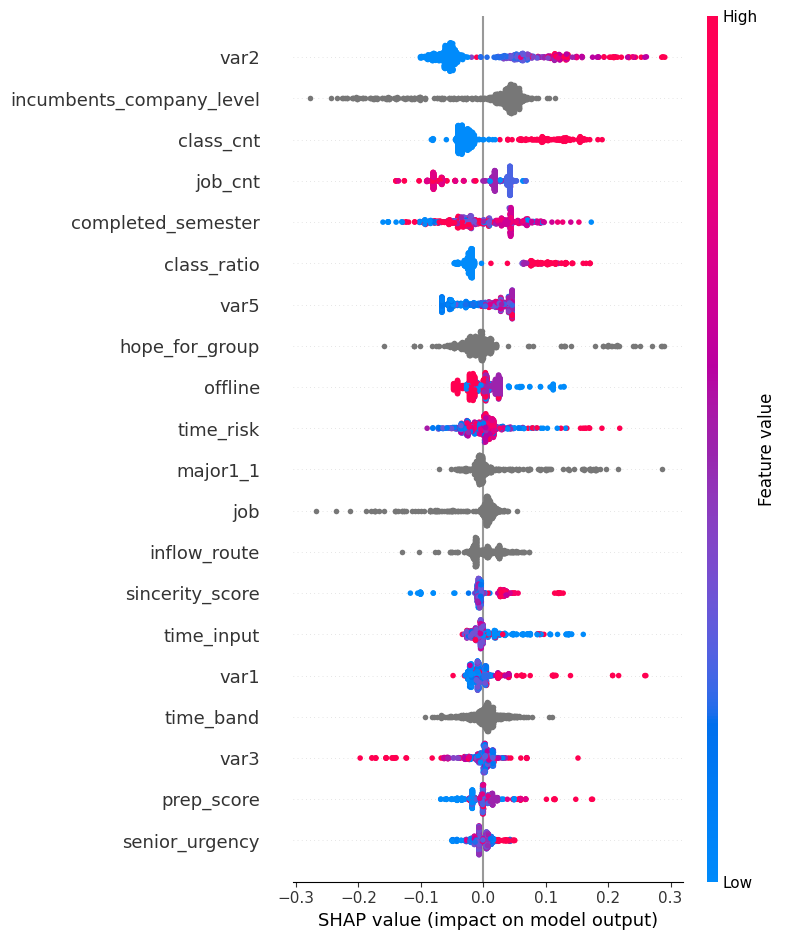

In [10]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)


In [11]:
import oof_pred
from sklearn.metrics import classification_report

y_pred = (oof_pred >= best_thr).astype(int)

print(classification_report(y, y_pred))


ModuleNotFoundError: No module named 'oof_pred'

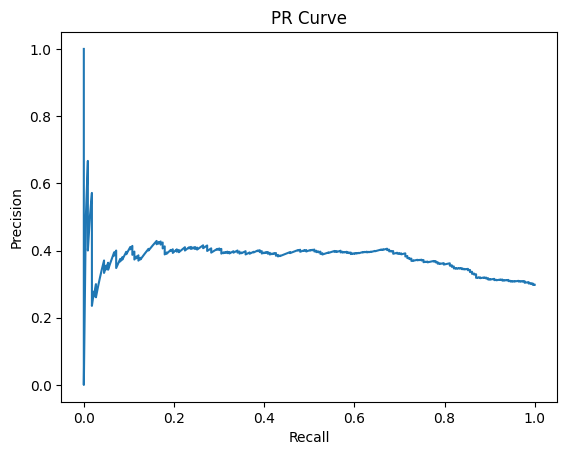

In [ ]:
from sklearn.metrics import precision_recall_curve

p,r,_ = precision_recall_curve(y, oof_pred)

plt.plot(r,p)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.show()


In [ ]:
y.mean()


np.float64(0.29812834224598933)

In [ ]:
y_pred.mean()

np.float64(0.5401069518716578)

In [ ]:
test_pred.mean()

np.float64(0.31652255278464553)

In [ ]:
print("Test pos rate @ best_thr:", (test_pred >= best_thr).mean())

Test pos rate @ best_thr: 0.6105651105651105


In [ ]:
# =========================
# 9) 제출 파일 생성
# =========================
sample = pd.read_csv("data/sample_submission.csv")

sub = sample.copy()
sub["completed"] = pred_test
sub.to_csv("0.61ratio.csv",index=False)

print("Saved:0.61ratio.csv")

Saved:0.61ratio.csv


### 0.61ratio.csv -> LB 점수 : 0.4289




##같은 모델 내부 앙상블 (variance 줄이기)


*   multi-seed + CV 앙상블
*   threshold 미세 튜닝

###Multi-seed + CV 앙상블 (variance 감소 + 안정화)

In [ ]:
seeds = [42, 202, 777, 2026, 9999]

oof_ens = np.zeros(len(X))
test_ens = np.zeros(len(X_test))

te_pool = Pool(X_test, cat_features=cat_features)

for s in seeds:
    print(f"\n===== SEED {s} =====")

    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test),dtype=float)

    #최적 파라미터 사용
    cb_params = dict(
        learning_rate=0.09870909742558537,
        depth=6,
        l2_leaf_reg=5.603795561726096,
        min_data_in_leaf=66,
        random_strength=6.478397173569881,
        iterations=2000,
        auto_class_weights=None,
        class_weights=None,
        loss_function='Logloss',
        eval_metric='AUC',
        custom_metric=["F1","AUC"],
        random_seed=s,
        early_stopping_rounds=200,
        verbose=200
    )

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        print(f"\n----- Fold {fold} -----")

        tr_pool = Pool(X.iloc[tr], y.iloc[tr], cat_features=cat_features)
        va_pool = Pool(X.iloc[va], y.iloc[va], cat_features=cat_features)

        model = CatBoostClassifier(**cb_params)
        model.fit(tr_pool, eval_set=va_pool, use_best_model=True)

        oof[va] = model.predict_proba(va_pool)[:, 1]
        test_pred += model.predict_proba(te_pool)[:, 1] / skf.n_splits

    # seed 하나 끝날 때마다 앙상블 누적
    oof_ens += oof / len(seeds)
    test_ens += test_pred / len(seeds)

print("\n앙상블 완료")
print("OOF mean/std:", oof_ens.mean(), oof_ens.std())
print("TEST mean/std:", test_ens.mean(), test_ens.std())


NameError: name 'X' is not defined

In [21]:
from sklearn.metrics import f1_score
import numpy as np

def ensemble_find_best_threshold(y_true, proba, t_min=0.05, t_max=0.95, step=0.002):
    best_f1, best_t = -1.0, None
    for t in np.arange(t_min, t_max + 1e-9, step):
        f1 = f1_score(y_true, (proba >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

best_thr, best_f1 = ensemble_find_best_threshold(y, oof_ens, 0.05, 0.95, 0.002)
print("Ensemble OOF best F1:", best_f1)
print("Ensemble best thr:", best_thr)

Ensemble OOF best F1: 0.502127659574468
Ensemble best thr: 0.2760000000000002


### 앙상블 전

oof best f1 : 0.5007974481658692

Best threshold: 0.29000000000000004

-------------------------------------------------------

### 앙상블 후

oof best f1 : 0.502127659574468 **(+0.00133 개선)**

Best threshold: 0.2760000000000002

앙상블로 인해 큰 개선은 없음, variance만 줄어듦

앙상블 평균이니까 threshold도 내려감



In [22]:
pred_thr = (test_ens >= best_thr).astype(int)
print("test pos rate(thr):", pred_thr.mean(), pred_thr.sum(), "/", len(pred_thr))

test pos rate(thr): 0.7604422604422605 619 / 814


In [23]:
print("OOF pos rate:", (oof_ens >= best_thr).mean())

OOF pos rate: 0.6443850267379679


###Threshold 미세 튜닝



In [ ]:
from sklearn.metrics import f1_score

t = 0.276
fold_f1 = []
fold_pos = []

for tr, va in skf.split(X, y):
    y_va = y.iloc[va]
    p_va = oof_ens[va]
    pred = (p_va >= t).astype(int)
    fold_f1.append(f1_score(y_va, pred))
    fold_pos.append(pred.mean())

print("fold f1:", fold_f1, "mean:", sum(fold_f1)/len(fold_f1))
print("fold pos:", fold_pos, "mean:", sum(fold_pos)/len(fold_pos))

#oof best threshold가 각 fold별로도 안정적

fold f1: [0.49019607843137253, 0.49070631970260226, 0.5258620689655172] mean: 0.5022548223664973
fold pos: [np.float64(0.516), np.float64(0.7831325301204819), np.float64(0.6345381526104418)] mean: 0.6445568942436412


In [32]:
#최고점 근처 후보들 중 가장 안장적인 상위 5% 출력

cut = np.quantile(rows[:,1], 0.95)  # 상위 5%
cand = rows[rows[:,1] >= cut]
cand = cand[np.lexsort((cand[:,2], -cand[:,1]))]
print(cand[:20])

[[0.276      0.50225482 0.01669414 0.49019608 0.64455689]
 [0.28       0.50171741 0.01445031 0.49056604 0.62450335]
 [0.289      0.50142105 0.016233   0.48582996 0.56165462]
 [0.278      0.50119837 0.01342112 0.4887218  0.63118072]
 [0.282      0.50056134 0.01900584 0.48461538 0.60577778]]


In [34]:
thr_final = 0.278

sub = sample.copy()
sub["completed"] = (test_ens >= thr_final).astype(int)
sub.to_csv("sub_ens_thr_0278.csv", index=False)

print("Saved: sub_ens_thr_0278.csv")
print("test pos rate:", (test_ens >= thr_final).mean())

Saved: sub_ens_thr_0278.csv
test pos rate: 0.7493857493857494


In [35]:
t1, t2 = 0.278, 0.280
p1 = (test_ens >= t1).astype(int)
p2 = (test_ens >= t2).astype(int)

diff = (p1 != p2).sum()
print("뒤집힌 개수:", diff)

뒤집힌 개수: 9


In [36]:
# 0.276~0.280 구간에 몇 개 있는지
mask = (test_ens >= 0.276) & (test_ens < 0.280)
print("경계 구간 표본 수:", mask.sum())

경계 구간 표본 수: 18


In [37]:
thr_final = 0.279

sub = sample.copy()
sub["completed"] = (test_ens >= thr_final).astype(int)
sub.to_csv("sub_ens_thr_0279.csv", index=False)

print("Saved: sub_ens_thr_0279.csv")
print("test pos rate:", (test_ens >= thr_final).mean())

Saved: sub_ens_thr_0279.csv
test pos rate: 0.742014742014742


In [38]:
t1, t2 = 0.279, 0.280

p1 = (test_ens >= t1).astype(int)
p2 = (test_ens >= t2).astype(int)

diff = (p1 != p2).sum()
print("뒤집힌 개수:", diff)

뒤집힌 개수: 3


In [39]:
mask = (test_ens >= 0.279) & (test_ens < 0.280)
print("0.279~0.280 구간 표본 수:", mask.sum())

0.279~0.280 구간 표본 수: 3


In [40]:
idx = np.where(p1 != p2)[0]
print("뒤집힌 확률들:")
print(np.sort(test_ens[idx]))

뒤집힌 확률들:
[0.27925031 0.27957185 0.27991824]


In [41]:
thr_final = 0.280

sub = sample.copy()
sub["completed"] = (test_ens >= thr_final).astype(int)
sub.to_csv("sub_ens_thr_028.csv", index=False)

print("Saved: sub_ens_thr_028.csv")
print("test pos rate:", (test_ens >= thr_final).mean())

Saved: sub_ens_thr_028.csv
test pos rate: 0.7383292383292384


### oof best threshold : 0.276 -> LB 점수 : 0.43176

### 0.278 -> LB 점수 : 0.435

### 0.279 -> LB 점수 : 0.4382871537

### 0.28  -> LB 점수 : 0.4365482234 (점수 하락)

---------------------------------------------------------

# [Conclusion]

### thr = 0.279

### test pos rate ≈ 0.742 (604개 정도를 1로 예측)

### public LB 최고: 0.4383

